# 03 — unified Supervised Autoencoder (pan-cell-type biomarkers)

**Design.** Target = binary `Class` (Normal=0, Tumor=1). Features = log-normalised
expression over the discovery∩validation gene space, standardised within each CV fold.
Cell type enters as an optional one-hot covariate (ablated in Part 2).

**Revision notes (v2) — what changed and why:**

1. **Feature space = intersection, not zero-fill.** Previously 46 HVGs absent from the
   validation cohort were zero-filled and then standardised with discovery statistics,
   injecting a large constant offset into every validation cell. We now model only genes
   present in *both* cohorts.
2. **Dissociation IEGs excluded from the primary model.** FOS/EGR1/KLF4/NR4A2/GADD45B and
   friends separate tumour from normal partly because the two tissues were dissociated
   separately. They are flagged in notebook 01 and toggled here (`EXCLUDE_IEG`) so the
   sensitivity analysis is one switch away.
3. **IG baseline = normal-cell centroid, not zeros.** After standardisation a value of 0
   is the *mean* cell, not a null cell, so the old "expression → 0" baseline answered the
   wrong counterfactual. The baseline is now the train-fold Normal centroid: attribution
   reads as "what moves this cell away from an average normal cell".
4. **Rank-based consensus + selection frequency.** Averaging raw |IG| is magnitude-
   confounded — highly expressed genes (B2M, HLA-B) dominate regardless of relevance.
   Attributions are ranked within each fold before aggregation, and every gene carries the
   fraction of fold-models in which it reached the top-N (a stability score).
5. **Signed attribution + log2FC.** `abs()` alone cannot distinguish a tumour-up gene
   (REG4) from a normal-marker lost in tumour (GUCA2A, PIGR). Both are now reported.
6. **Out-of-fold predictions retained** so the decision threshold is chosen on discovery
   only and frozen before validation is touched.
7. **Optional per-cell-type `pos_weight`.** A global weight leaves the epithelial
   compartment 25:1 imbalanced inside the pooled model.

In [2]:
# ============================================================
# 0. Imports, determinism, configuration
# ============================================================
import os, warnings, random, json
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import scanpy as sc
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset

from scipy.stats import rankdata
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (roc_auc_score, average_precision_score,
                             balanced_accuracy_score, f1_score, roc_curve)

try:
    from captum.attr import IntegratedGradients
    CAPTUM_AVAILABLE = True
except ImportError:
    IntegratedGradients = None
    CAPTUM_AVAILABLE = False
    print("captum not installed. Run: pip install captum -q")

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)
if DEVICE.type == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))

def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# ============================================================
# CONFIGURATION — declared a priori, not tuned on validation
# ============================================================
DISC_DIR   = "gse132465_preprocessing_outputs_before_Xm"
DISC_PATH  = os.path.join(DISC_DIR, "GSE132465_DL_ready_HVG3000_celllevel.h5ad")
VAL_PATH   = "GSE144735_DL_ready.h5ad"
SHARED_CSV = "shared_feature_space.csv"
OUT_DIR    = "optionB_outputs"
os.makedirs(OUT_DIR, exist_ok=True)

KEEP_TYPES  = ["T cells", "Epithelial cells", "B cells", "Myeloids", "Stromal cells"]
EXCLUDE_IEG = True          # primary analysis; False = dissociation sensitivity
USE_ONEHOT  = True          # primary; ablation in Part 2
NORM_LAYER  = "batch"       # "batch" | "layer"  (layer often transfers better)
POS_WEIGHT  = "per_celltype"  # "global" | "per_celltype"

SEEDS       = (0, 1, 2)
N_SPLITS    = 5
EPOCHS      = 40            # same value everywhere: CV, full-fit, transfer
BATCH_SIZE  = 512
LR          = 5e-4
BOTTLENECK  = 32
HIDDEN      = 1024
P_DROP      = 0.5
ALPHA_RECON = 0.5
BETA_CLF    = 2.0

TOP_N       = 100           # candidate panel size
IG_STEPS    = 64
IG_MAXCELLS = 2000

print(json.dumps({k: str(v) for k, v in dict(
    EXCLUDE_IEG=EXCLUDE_IEG, USE_ONEHOT=USE_ONEHOT, NORM_LAYER=NORM_LAYER,
    POS_WEIGHT=POS_WEIGHT, EPOCHS=EPOCHS, TOP_N=TOP_N, IG_STEPS=IG_STEPS).items()}, indent=2))

Device: cuda
GPU: NVIDIA GeForce RTX 5090
{
  "EXCLUDE_IEG": "True",
  "USE_ONEHOT": "True",
  "NORM_LAYER": "batch",
  "POS_WEIGHT": "per_celltype",
  "EPOCHS": "40",
  "TOP_N": "100",
  "IG_STEPS": "64"
}


In [3]:
# ============================================================
# 1. Discovery data + shared (intersection) feature space
# ============================================================
adata = sc.read_h5ad(DISC_PATH)
class_col, celltype_col = "Class", "Cell_type"
patient_col = "Patient" if "Patient" in adata.obs.columns else "Sample"

adata = adata[adata.obs[celltype_col].isin(KEEP_TYPES)].copy()
print("After cell-type filter:", adata.shape)

# ---- shared gene space: discovery HVG ∩ validation ----
if os.path.exists(SHARED_CSV):
    shared = pd.read_csv(SHARED_CSV)["gene"].tolist()
    print(f"Loaded shared feature space: {len(shared)} genes")
else:                                    # fallback: recompute
    val_tmp = sc.read_h5ad(VAL_PATH)
    hvg = adata.var_names[adata.var["highly_variable"]].tolist()
    shared = sorted(set(hvg) & set(val_tmp.var_names))
    pd.DataFrame({"gene": shared}).to_csv(SHARED_CSV, index=False)
    del val_tmp
    print(f"Computed shared feature space: {len(shared)} genes")

# ---- dissociation IEG exclusion ----
ieg_in_space = [g for g in shared
                if g in adata.var_names and bool(adata.var.loc[g, "dissociation_ieg"])]
print(f"Dissociation IEGs inside shared space: {len(ieg_in_space)} -> {sorted(ieg_in_space)}")

if EXCLUDE_IEG:
    feature_genes = [g for g in shared if g not in set(ieg_in_space)]
    print(f"PRIMARY model: IEGs EXCLUDED. Features: {len(feature_genes)}")
else:
    feature_genes = list(shared)
    print(f"SENSITIVITY model: IEGs RETAINED. Features: {len(feature_genes)}")

adata = adata[:, feature_genes].copy()
pd.DataFrame({"gene": feature_genes}).to_csv(
    os.path.join(OUT_DIR, "optionB_feature_genes.csv"), index=False)

print("\nModelling object:", adata.shape)
print(pd.crosstab(adata.obs[celltype_col], adata.obs[class_col]))

After cell-type filter: (61762, 25157)
Loaded shared feature space: 2954 genes
Dissociation IEGs inside shared space: 20 -> ['ATF3', 'CEBPD', 'CYR61', 'DUSP1', 'EGR1', 'EGR2', 'EGR3', 'FOS', 'FOSB', 'GADD45B', 'IER3', 'JUNB', 'KLF2', 'KLF4', 'NR4A2', 'NR4A3', 'RHOB', 'SOCS3', 'ZFP36', 'ZNF331']
PRIMARY model: IEGs EXCLUDED. Features: 2934

Modelling object: (61762, 2934)
Class             Normal  Tumor
Cell_type                      
B cells             5177   3933
Epithelial cells     670  16877
Myeloids             367   6159
Stromal cells       3021   2617
T cells             6312  16629


| Cell barcode | CFD | PHGR1 | TFF3 | DCN | EPCAM | ... | Gene\_2934 | B\_cells | Epithelial\_cells | Myeloids | Stromal\_cells | T\_cells |
| --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- |
| Cell\_001 | 0.42 | 1.18 | 0.00 | 2.04 | 0.73 | ... | 0.11 | 0 | 1 | 0 | 0 | 0 |
| Cell\_002 | 1.03 | 0.00 | 2.37 | 0.41 | 0.00 | ... | 0.54 | 0 | 1 | 0 | 0 | 0 |
| Cell\_003 | 0.00 | 0.24 | 0.91 | 1.35 | 0.00 | ... | 0.00 | 0 | 0 | 0 | 0 | 1 |
| Cell\_004 | 0.76 | 0.52 | 1.87 | 0.00 | 0.12 | ... | 0.92 | 0 | 0 | 1 | 0 | 0 |
| Cell\_005 | 1.21 | 0.00 | 0.33 | 0.85 | 0.00 | ... | 0.18 | 1 | 0 | 0 | 0 | 0 |
| Cell\_006 | 0.09 | 0.61 | 0.00 | 1.72 | 0.04 | ... | 0.47 | 0 | 0 | 0 | 1 | 0 |

In [4]:
# ============================================================
# 2. Feature matrix, labels, groups + composition baseline
# ============================================================
X = adata.X
X_expr = np.asarray(X.todense()) if hasattr(X, "todense") else np.asarray(X)
X_expr = X_expr.astype(np.float32)

gene_names = adata.var_names.to_numpy()
y      = (adata.obs[class_col].astype(str).values == "Tumor").astype(np.int64)
groups = adata.obs[patient_col].astype(str).values
ct_str = adata.obs[celltype_col].astype(str).values

ct_dummies = pd.get_dummies(pd.Series(ct_str), prefix="ct")
ct_cols    = ct_dummies.columns.tolist()
X_ct       = ct_dummies.values.astype(np.float32)
ct_ids     = np.argmax(X_ct, axis=1)                 # integer cell-type index

n_genes = X_expr.shape[1]
n_ct    = X_ct.shape[1] if USE_ONEHOT else 0

print(f"Genes: {n_genes} | cell-type covariates: {n_ct} (USE_ONEHOT={USE_ONEHOT})")
print(f"Cells: {len(y):,} | tumor fraction: {y.mean():.3f} | patients: {len(np.unique(groups))}")

# ---------- composition baseline: what does cell type ALONE achieve? ----------
# The one-hot covariate is intended as an adjustment, but in a nonlinear model it also
# carries label information. This floor must be reported so gene-level performance can
# be read against it.
rows = []
for c in ct_cols:
    m = ct_dummies[c].values.astype(bool)
    rows.append({"cell_type": c, "n": int(m.sum()),
                 "tumor_frac": float(y[m].mean())})
comp = pd.DataFrame(rows)
print("\nTumor fraction by cell type (discovery):")
print(comp.to_string(index=False))

prior = comp.set_index("cell_type")["tumor_frac"].to_dict()
prob_ct = np.array([prior[ct_cols[i]] for i in ct_ids])
pred_ct = (prob_ct >= 0.5).astype(int)
BASE_CT = {"roc_auc": roc_auc_score(y, prob_ct),
           "bal_acc": balanced_accuracy_score(y, pred_ct)}
print(f"\n*** CELL-TYPE-ONLY BASELINE: ROC-AUC={BASE_CT['roc_auc']:.3f} "
      f"balAcc={BASE_CT['bal_acc']:.3f} — the model must clearly beat this. ***")
pd.DataFrame([BASE_CT]).to_csv(os.path.join(OUT_DIR, "baseline_celltype_only.csv"), index=False)

Genes: 2934 | cell-type covariates: 5 (USE_ONEHOT=True)
Cells: 61,762 | tumor fraction: 0.748 | patients: 23

Tumor fraction by cell type (discovery):
          cell_type     n  tumor_frac
         ct_B cells  9110    0.431723
ct_Epithelial cells 17547    0.961817
        ct_Myeloids  6526    0.943763
   ct_Stromal cells  5638    0.464172
         ct_T cells 22941    0.724859

*** CELL-TYPE-ONLY BASELINE: ROC-AUC=0.785 balAcc=0.693 — the model must clearly beat this. ***


## Supervised Autoencoder architecture
SAE model gene-expression pattern ব্যবহার করে একটি low-dimensional latent representation শেখে।  
এই latent representation একই সঙ্গে gene-expression reconstruct এবং Tumor/Normal classification-এর জন্য ব্যবহার করা হয়।

### Model input

- 2,934 gene-expression features
- 5 cell-type indicator features
- Total input dimension = 2,939 features

### Encoder

```text
2,939 input features
        ↓
Hidden layer
        ↓
Hidden layer
        ↓
32-dimensional latent vector

In [5]:
# ============================================================
# 3. Supervised autoencoder
# ============================================================
class SupervisedAE(nn.Module):
    """Encoder → bottleneck z; decoder reconstructs the EXPRESSION block only
    (regulariser); classifier predicts Tumor from z.

    NORM_LAYER='layer' uses LayerNorm instead of BatchNorm. BatchNorm stores running
    statistics estimated on the discovery cohort, which are wrong for an external cohort;
    LayerNorm normalises per cell and is therefore cohort-agnostic."""

    def __init__(self, n_genes, n_ct=0, bottleneck=BOTTLENECK, hidden=HIDDEN,
                 p_drop=P_DROP, norm=NORM_LAYER):
        super().__init__()
        self.n_genes = n_genes
        in_dim = n_genes + n_ct
        Norm = (lambda d: nn.BatchNorm1d(d)) if norm == "batch" else (lambda d: nn.LayerNorm(d))

        self.encoder = nn.Sequential(
            nn.Linear(in_dim, hidden),      Norm(hidden),      nn.ReLU(), nn.Dropout(p_drop),
            nn.Linear(hidden, hidden // 2), Norm(hidden // 2), nn.ReLU(), nn.Dropout(p_drop),
            nn.Linear(hidden // 2, bottleneck),
        )
        self.decoder = nn.Sequential(
            nn.Linear(bottleneck, hidden // 2), nn.ReLU(),
            nn.Linear(hidden // 2, hidden),     nn.ReLU(),
            nn.Linear(hidden, n_genes),
        )
        self.classifier = nn.Sequential(
            nn.Linear(bottleneck, 64), nn.ReLU(), nn.Dropout(p_drop),
            nn.Linear(64, 1),
        )

    def forward(self, x):
        z = self.encoder(x)
        return self.classifier(z).squeeze(-1), self.decoder(z), x[:, :self.n_genes]

    def predict_logit(self, x):
        return self.classifier(self.encoder(x)).squeeze(-1)

In [6]:
# ============================================================
# 4. Fold training (per-cell-type class weighting)
# ============================================================
def make_weights(y_arr, ct_arr, mode=POS_WEIGHT):
    """Per-cell BCE weight. 'per_celltype' equalises Tumor/Normal WITHIN each lineage,
    so the 25:1 epithelial imbalance is not absorbed by a single global constant."""
    w = np.ones(len(y_arr), dtype=np.float32)
    if mode == "global":
        n_pos = max(float(y_arr.sum()), 1.0)
        w[y_arr == 1] = (len(y_arr) - n_pos) / n_pos
        return w
    for c in np.unique(ct_arr):
        m = ct_arr == c
        n_pos = float(y_arr[m].sum()); n_neg = float(m.sum() - n_pos)
        if n_pos > 0 and n_neg > 0:
            w[m & (y_arr == 1)] = n_neg / n_pos
    return w


def train_one_fold(Xtr, ytr, wtr, n_genes, n_ct, seed=42, epochs=EPOCHS, verbose=False):
    set_seed(seed)
    model = SupervisedAE(n_genes, n_ct).to(DEVICE)
    opt = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=1e-5)

    ds = TensorDataset(torch.tensor(Xtr, dtype=torch.float32),
                       torch.tensor(ytr, dtype=torch.float32),
                       torch.tensor(wtr, dtype=torch.float32))
    g = torch.Generator(); g.manual_seed(seed)
    dl = DataLoader(ds, batch_size=BATCH_SIZE, shuffle=True, generator=g, drop_last=True)

    for ep in range(epochs):
        model.train(); running = 0.0
        for xb, yb, wb in dl:
            xb, yb, wb = xb.to(DEVICE), yb.to(DEVICE), wb.to(DEVICE)
            opt.zero_grad()
            logit, recon, x_expr = model(xb)
            loss = (ALPHA_RECON * F.mse_loss(recon, x_expr)
                    + BETA_CLF * F.binary_cross_entropy_with_logits(logit, yb, weight=wb))
            loss.backward(); opt.step()
            running += loss.item()
        if verbose and (ep + 1) % 10 == 0:
            print(f"    epoch {ep+1}: loss={running/len(dl):.4f}")
    return model


@torch.no_grad()
def predict_prob(model, X, batch=8192):
    model.eval(); out = []
    for i in range(0, len(X), batch):
        xb = torch.tensor(X[i:i+batch], dtype=torch.float32, device=DEVICE)
        out.append(torch.sigmoid(model.predict_logit(xb)).cpu().numpy())
    return np.concatenate(out)


def score(y_true, prob, thr=0.5):
    pred = (prob >= thr).astype(int)
    return {"roc_auc": roc_auc_score(y_true, prob) if len(np.unique(y_true)) > 1 else np.nan,
            "pr_auc":  average_precision_score(y_true, prob) if len(np.unique(y_true)) > 1 else np.nan,
            "bal_acc": balanced_accuracy_score(y_true, pred),
            "f1":      f1_score(y_true, pred, zero_division=0)}

In [8]:
# ============================================================
# 5. Integrated Gradients with a NORMAL-CENTROID baseline
# ============================================================
def attribute_fold(model, Xte, yte, n_genes, base_expr, seed=42,
                   max_cells=IG_MAXCELLS, steps=IG_STEPS):
    """IG on held-out TUMOUR cells w.r.t. the Tumor logit.

    Baseline = train-fold Normal centroid in standardised space (one-hot columns copied
    from each cell, so only expression varies along the path). This answers
    'what moves this cell away from an average normal cell', which is the correct
    counterfactual for a Tumor-vs-Normal biomarker. A zeros baseline would instead
    interpolate from the *mean* cell, because standardised 0 == mean expression.

    Returns (mean_abs, mean_signed, per_cell_abs, ct_index_per_cell, mean_|delta|).
    """
    if IntegratedGradients is None:
        raise ImportError("captum not installed.")
    set_seed(seed); model.eval()

    idx = np.where(yte == 1)[0]
    if len(idx) == 0:
        return (np.zeros(n_genes), np.zeros(n_genes),
                np.zeros((0, n_genes)), np.zeros(0, dtype=int), np.nan)
    if len(idx) > max_cells:
        idx = np.random.RandomState(seed).choice(idx, max_cells, replace=False)

    X_attr   = torch.tensor(Xte[idx], dtype=torch.float32, device=DEVICE)
    baseline = X_attr.clone()
    baseline[:, :n_genes] = torch.tensor(base_expr, dtype=torch.float32, device=DEVICE)

    ig = IntegratedGradients(model.predict_logit)
    attr, delta = ig.attribute(X_attr, baselines=baseline, n_steps=steps,
                               internal_batch_size=4096, return_convergence_delta=True)
    attr = attr.detach().cpu().numpy()[:, :n_genes]

    ct_idx = (X_attr[:, n_genes:].argmax(dim=1).cpu().numpy()
              if X_attr.shape[1] > n_genes else np.zeros(len(idx), dtype=int))

    return (np.abs(attr).mean(0), attr.mean(0), np.abs(attr), ct_idx,
            float(np.abs(delta.detach().cpu().numpy()).mean()))

In [9]:
# ============================================================
# 6. Patient-grouped CV with rank-based attribution consensus
# ============================================================
def run_cv(X_expr, X_ct, y, groups, ct_ids, gene_names,
           seeds=SEEDS, n_splits=N_SPLITS, do_attribution=True,
           tag="cv", ct_names=None, epochs=EPOCHS, top_n=TOP_N):

    n_genes  = X_expr.shape[1]
    n_ct_use = X_ct.shape[1] if (X_ct is not None and USE_ONEHOT) else 0
    n_groups = len(np.unique(groups))
    n_splits = min(n_splits, n_groups)
    if n_splits < 2:
        raise ValueError(f"[{tag}] need >=2 patient groups, got {n_groups}.")
    print(f"[{tag}] cells={len(y):,} patients={n_groups} folds={n_splits} "
          f"tumor_frac={y.mean():.3f}")

    all_metrics, deltas = [], []
    oof = np.full((len(seeds), len(y)), np.nan, dtype=np.float32)

    rank_acc = np.zeros(n_genes); sel_acc = np.zeros(n_genes)
    sign_acc = np.zeros(n_genes); abs_acc = np.zeros(n_genes); n_attr = 0

    collect_ct = do_attribution and (ct_names is not None) and USE_ONEHOT
    if collect_ct:
        ct_sum = np.zeros((n_genes, len(ct_names))); ct_cnt = np.zeros(len(ct_names))

    for si, seed in enumerate(seeds):
        sgkf = StratifiedGroupKFold(n_splits=n_splits, shuffle=True, random_state=seed)
        for fold, (tr, te) in enumerate(sgkf.split(X_expr, y, groups=groups), start=1):

            scaler = StandardScaler().fit(X_expr[tr])          # train fold only
            Xtr_e  = scaler.transform(X_expr[tr]).astype(np.float32)
            Xte_e  = scaler.transform(X_expr[te]).astype(np.float32)

            if n_ct_use:
                Xtr = np.hstack([Xtr_e, X_ct[tr]]).astype(np.float32)
                Xte = np.hstack([Xte_e, X_ct[te]]).astype(np.float32)
            else:
                Xtr, Xte = Xtr_e, Xte_e

            wtr = make_weights(y[tr], ct_ids[tr])
            model = train_one_fold(Xtr, y[tr], wtr, n_genes, n_ct_use, seed=seed, epochs=epochs)

            prob = predict_prob(model, Xte)
            oof[si, te] = prob
            m = score(y[te], prob)
            m.update({"seed": seed, "fold": fold,
                      "n_test_patients": len(np.unique(groups[te]))})
            all_metrics.append(m)
            print(f"[{tag}] seed {seed} fold {fold}: ROC-AUC={m['roc_auc']:.3f} "
                  f"PR-AUC={m['pr_auc']:.3f} balAcc={m['bal_acc']:.3f}")

            if do_attribution and CAPTUM_AVAILABLE:
                try:
                    base_expr = Xtr_e[y[tr] == 0].mean(0)      # NORMAL centroid, train fold
                    a_abs, a_sign, per_cell, ctv, dlt = attribute_fold(
                        model, Xte, y[te], n_genes, base_expr, seed=seed)
                    # rank within fold (1 = strongest) -> magnitude-invariant consensus
                    r = rankdata(-a_abs, method="average")
                    rank_acc += r
                    sel_acc  += (r <= top_n).astype(float)
                    sign_acc += a_sign
                    abs_acc  += a_abs
                    deltas.append(dlt); n_attr += 1
                    if collect_ct and len(ctv):
                        for c in range(len(ct_names)):
                            mc = ctv == c
                            if mc.any():
                                ct_sum[:, c] += per_cell[mc].sum(0); ct_cnt[c] += mc.sum()
                except Exception as e:
                    print(f"  attribution skipped (seed {seed} fold {fold}): {e}")

    metrics_df = pd.DataFrame(all_metrics)
    # fold-level mean over seeds first, THEN spread across folds (seeds share splits)
    per_fold = metrics_df.groupby("fold")[["roc_auc", "pr_auc", "bal_acc", "f1"]].mean()
    print(f"\n=== [{tag}] summary (mean over seeds, ±SD across folds) ===")
    print(pd.DataFrame({"mean": per_fold.mean(), "sd_across_folds": per_fold.std()}).round(4))

    rank_df = None
    if n_attr > 0:
        rank_df = (pd.DataFrame({
            "gene": gene_names,
            "mean_rank":        rank_acc / n_attr,
            "selection_freq":   sel_acc / n_attr,
            "mean_abs_attr":    abs_acc / n_attr,
            "mean_signed_attr": sign_acc / n_attr,
        }).sort_values(["mean_rank"]).reset_index(drop=True))
        rank_df["rank"] = np.arange(1, len(rank_df) + 1)
        print(f"[{tag}] IG convergence |delta| = {np.mean(deltas):.4f} "
              f"(fold-models used: {n_attr})")

    extras = {"oof": np.nanmean(oof, axis=0), "oof_per_seed": oof, "ct_attr": None}
    if collect_ct and ct_cnt.sum() > 0:
        denom = np.where(ct_cnt == 0, np.nan, ct_cnt)[None, :]
        extras["ct_attr"] = pd.DataFrame(ct_sum / denom, index=gene_names,
                                         columns=list(ct_names)).fillna(0.0)
    return metrics_df, rank_df, extras

In [10]:
# ============================================================
# 7. Discovery CV
# ============================================================
metrics_disc, rank_df, disc_extras = run_cv(
    X_expr, X_ct, y, groups, ct_ids, gene_names,
    tag="discovery", ct_names=ct_cols, do_attribution=True)

metrics_disc.to_csv(os.path.join(OUT_DIR, "optionB_cv_metrics.csv"), index=False)
if rank_df is None:
    raise RuntimeError("No attribution produced — install captum and re-run.")

print(f"\nCell-type-only floor: balAcc={BASE_CT['bal_acc']:.3f} "
      f"| model: balAcc={metrics_disc['bal_acc'].mean():.3f}")

[discovery] cells=61,762 patients=23 folds=5 tumor_frac=0.748
[discovery] seed 0 fold 1: ROC-AUC=0.988 PR-AUC=0.996 balAcc=0.942
[discovery] seed 0 fold 2: ROC-AUC=0.955 PR-AUC=0.981 balAcc=0.884
[discovery] seed 0 fold 3: ROC-AUC=0.991 PR-AUC=0.997 balAcc=0.952
[discovery] seed 0 fold 4: ROC-AUC=0.986 PR-AUC=0.995 balAcc=0.933
[discovery] seed 0 fold 5: ROC-AUC=0.980 PR-AUC=0.990 balAcc=0.909
[discovery] seed 1 fold 1: ROC-AUC=0.988 PR-AUC=0.995 balAcc=0.940
[discovery] seed 1 fold 2: ROC-AUC=0.962 PR-AUC=0.984 balAcc=0.888
[discovery] seed 1 fold 3: ROC-AUC=0.991 PR-AUC=0.997 balAcc=0.953
[discovery] seed 1 fold 4: ROC-AUC=0.982 PR-AUC=0.993 balAcc=0.930
[discovery] seed 1 fold 5: ROC-AUC=0.978 PR-AUC=0.989 balAcc=0.908
[discovery] seed 2 fold 1: ROC-AUC=0.987 PR-AUC=0.995 balAcc=0.936
[discovery] seed 2 fold 2: ROC-AUC=0.959 PR-AUC=0.981 balAcc=0.885
[discovery] seed 2 fold 3: ROC-AUC=0.992 PR-AUC=0.997 balAcc=0.952
[discovery] seed 2 fold 4: ROC-AUC=0.988 PR-AUC=0.995 balAcc=0.941


#শুধু cell type দেখে Tumor/Normal অনুমান করলে balanced accuracy 69.3% পাওয়া যায়।

In [11]:
# ============================================================
# 8. Threshold frozen on discovery OOF + candidate panel
# ============================================================
oof_prob = disc_extras["oof"]
mask = ~np.isnan(oof_prob)
fpr, tpr, thr = roc_curve(y[mask], oof_prob[mask])
BEST_THR = float(thr[np.argmax(tpr - fpr)])          # Youden's J, discovery only

print(f"Discovery OOF: ROC-AUC={roc_auc_score(y[mask], oof_prob[mask]):.4f}")
print(f"balAcc @0.50 = {balanced_accuracy_score(y[mask], (oof_prob[mask] >= 0.5).astype(int)):.4f}")
print(f"balAcc @thr  = {balanced_accuracy_score(y[mask], (oof_prob[mask] >= BEST_THR).astype(int)):.4f}")
print(f"*** FROZEN THRESHOLD = {BEST_THR:.4f} — not re-tuned on validation. ***")

np.save(os.path.join(OUT_DIR, "optionB_oof_prob.npy"), oof_prob)
json.dump({"BEST_THR": BEST_THR, "TOP_N": TOP_N, "EXCLUDE_IEG": EXCLUDE_IEG,
           "USE_ONEHOT": USE_ONEHOT, "NORM_LAYER": NORM_LAYER,
           "POS_WEIGHT": POS_WEIGHT, "n_features": int(n_genes)},
          open(os.path.join(OUT_DIR, "optionB_frozen_config.json"), "w"), indent=2)

# ---------- direction: log2FC (tumour vs normal), pseudobulk by patient ----------
pb = pd.DataFrame(X_expr, columns=gene_names)
pb["pat"], pb["cls"] = groups, y
pbm = pb.groupby(["pat", "cls"])[list(gene_names)].mean().reset_index()
mu_t = pbm.loc[pbm["cls"] == 1, gene_names].mean()
mu_n = pbm.loc[pbm["cls"] == 0, gene_names].mean()
log2fc = (mu_t - mu_n).reindex(gene_names)           # log1p space difference

rank_df["log2fc_tumor_vs_normal"] = log2fc.values
rank_df["direction"] = np.where(rank_df["log2fc_tumor_vs_normal"] > 0, "UP_in_tumor",
                                "DOWN_in_tumor")
rank_df["is_candidate_biomarker"] = rank_df["rank"] <= TOP_N
rank_df.to_csv(os.path.join(OUT_DIR, "optionB_gene_attribution_ranking.csv"), index=False)

candidate_genes = rank_df.loc[rank_df["is_candidate_biomarker"], "gene"].tolist()
np.save(os.path.join(OUT_DIR, "optionB_candidate_genes.npy"), np.array(candidate_genes))

print(f"\nCandidate panel: {len(candidate_genes)} genes")
print(rank_df.head(30)[["rank", "gene", "mean_rank", "selection_freq",
                        "log2fc_tumor_vs_normal", "direction"]].to_string(index=False))
print("\nDirection split in panel:")
print(rank_df.loc[rank_df["is_candidate_biomarker"], "direction"].value_counts())
print(f"Panel genes with selection_freq == 1.0 (all 15 fold-models): "
      f"{int((rank_df.loc[rank_df['is_candidate_biomarker'], 'selection_freq'] == 1.0).sum())}")

Discovery OOF: ROC-AUC=0.9822
balAcc @0.50 = 0.9307
balAcc @thr  = 0.9329
*** FROZEN THRESHOLD = 0.6616 — not re-tuned on validation. ***

Candidate panel: 100 genes
 rank       gene  mean_rank  selection_freq  log2fc_tumor_vs_normal     direction
    1        CFD   1.800000             1.0               -0.294895 DOWN_in_tumor
    2        B2M   2.000000             1.0                0.002626   UP_in_tumor
    3      PHGR1   2.200000             1.0                0.014313   UP_in_tumor
    4       TFF3   7.600000             1.0               -0.173018 DOWN_in_tumor
    5      CLDN4   9.000000             1.0               -0.042254 DOWN_in_tumor
    6        DCN   9.000000             1.0                0.002095   UP_in_tumor
    7     GUCA2A  10.400000             1.0               -0.000541 DOWN_in_tumor
    8      CXCL8  11.133333             1.0                0.000851   UP_in_tumor
    9      KRT18  11.400000             1.0               -0.022590 DOWN_in_tumor
   10   ADAMDE

  N  mean_selection_freq  frac_freq_1.0
 25                1.000          1.000
 50                0.983          0.860
 75                0.896          0.587
100                0.769          0.440
150                0.584          0.293
200                0.460          0.220
300                0.319          0.147


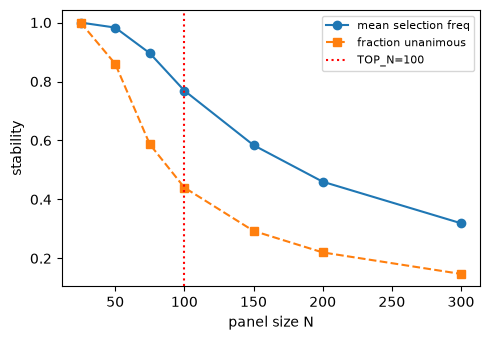

In [12]:
# ============================================================
# 9. Is TOP_N = 100 defensible? (discovery-only evidence)
# ============================================================
# Chosen a priori, but reviewers ask "why 100?". Selection frequency as a function of
# rank shows where the ranking stops being stable — computed WITHOUT touching validation.
curve = []
for N in [25, 50, 75, 100, 150, 200, 300]:
    sub = rank_df.head(N)
    curve.append({"N": N,
                  "mean_selection_freq": sub["selection_freq"].mean().round(3),
                  "frac_freq_1.0": (sub["selection_freq"] == 1.0).mean().round(3)})
curve = pd.DataFrame(curve)
print(curve.to_string(index=False))
curve.to_csv(os.path.join(OUT_DIR, "optionB_panel_size_curve.csv"), index=False)

fig, ax = plt.subplots(figsize=(5, 3.5))
ax.plot(curve["N"], curve["mean_selection_freq"], "o-", label="mean selection freq")
ax.plot(curve["N"], curve["frac_freq_1.0"], "s--", label="fraction unanimous")
ax.axvline(TOP_N, color="r", ls=":", label=f"TOP_N={TOP_N}")
ax.set_xlabel("panel size N"); ax.set_ylabel("stability"); ax.legend(fontsize=8)
plt.tight_layout(); plt.savefig(os.path.join(OUT_DIR, "panel_size_curve.png"), dpi=150)
plt.show()

In [13]:
# ============================================================
# 10. PATCH: composition-adjusted direction
# ============================================================
#OOf--> Out-of-Fold
# epithelial, tumour samples 36.5%, so epithelial-restricted genes (GUCA2A, KRT8) are
# diluted to ~0 and their sign becomes noise. We compute log2FC WITHIN each cell type
# (patient x cell type x class), then average across cell types with equal weight.

pb = pd.DataFrame(X_expr, columns=gene_names)
pb["pat"], pb["cls"], pb["ct"] = groups, y, ct_str
pbm = pb.groupby(["pat", "ct", "cls"], observed=True)[list(gene_names)].mean().reset_index()

fc_by_ct = {}
for c in sorted(pbm["ct"].unique()):
    s = pbm[pbm["ct"] == c]
    t, n = s[s["cls"] == 1], s[s["cls"] == 0]
    if len(t) >= 3 and len(n) >= 3:
        fc_by_ct[c] = (t[gene_names].mean() - n[gene_names].mean()).reindex(gene_names)

fc_mat = pd.DataFrame(fc_by_ct)
lfc_adj = fc_mat.mean(axis=1)
lfc_epi = fc_mat["Epithelial cells"] if "Epithelial cells" in fc_mat else lfc_adj

rank_df["lfc_adjusted"]  = lfc_adj.reindex(rank_df["gene"]).values
rank_df["lfc_epithelial"] = lfc_epi.reindex(rank_df["gene"]).values
rank_df["direction"] = np.where(rank_df["lfc_adjusted"] > 0, "UP_in_tumor", "DOWN_in_tumor")
rank_df["direction_ig"] = np.where(rank_df["mean_signed_attr"] > 0, "UP_in_tumor", "DOWN_in_tumor")
rank_df["direction_concordant"] = rank_df["direction"] == rank_df["direction_ig"]

panel = rank_df[rank_df["is_candidate_biomarker"]]
print("Direction (composition-adjusted):"); print(panel["direction"].value_counts())
print(f"IG-vs-expression concordance in panel: "
      f"{100 * panel['direction_concordant'].mean():.1f}%")
print("\nSanity — known normal-mucosa markers should be DOWN:")
print(rank_df.set_index("gene").reindex(
    ["GUCA2A", "GUCA2B", "ZG16", "CFD", "ADAMDEC1", "AQP8", "CLCA4"])
    [["lfc_adjusted", "lfc_epithelial", "direction"]].dropna().round(3))
print("\nKnown tumour markers should be UP:")
print(rank_df.set_index("gene").reindex(
    ["REG4", "S100P", "LCN2", "CLDN4", "AGR2", "TFF1", "CEACAM6", "SPINK1"])
    [["lfc_adjusted", "lfc_epithelial", "direction"]].dropna().round(3))

rank_df.to_csv(os.path.join(OUT_DIR, "optionB_gene_attribution_ranking.csv"), index=False)

# unannotated clone-based IDs will silently drop out of GO/KEGG/STRING later
odd = [g for g in candidate_genes if g.startswith(("AL", "AC", "AP0", "LINC", "Z9")) or "." in g]
print("\nNon-HGNC identifiers in panel (flag for downstream):", odd)

Direction (composition-adjusted):
direction
UP_in_tumor      56
DOWN_in_tumor    44
Name: count, dtype: int64
IG-vs-expression concordance in panel: 53.0%

Sanity — known normal-mucosa markers should be DOWN:
          lfc_adjusted  lfc_epithelial      direction
gene                                                 
GUCA2A          -0.346          -0.701  DOWN_in_tumor
GUCA2B          -0.302          -0.543  DOWN_in_tumor
ZG16            -0.359          -0.741  DOWN_in_tumor
CFD             -0.739          -0.264  DOWN_in_tumor
ADAMDEC1        -0.348          -0.127  DOWN_in_tumor
AQP8            -0.083          -0.153  DOWN_in_tumor
CLCA4           -0.049          -0.111  DOWN_in_tumor

Known tumour markers should be UP:
         lfc_adjusted  lfc_epithelial    direction
gene                                              
REG4            0.228           0.556  UP_in_tumor
S100P           0.397           1.283  UP_in_tumor
LCN2            0.336           0.919  UP_in_tumor
CLDN4         

In [14]:
# ============================================================
# 11. Validation cohort on the SAME feature space
# ============================================================
val = sc.read_h5ad(VAL_PATH)
val = val[val.obs[celltype_col].isin(KEEP_TYPES)].copy()

missing = [g for g in feature_genes if g not in set(val.var_names)]
assert len(missing) == 0, f"{len(missing)} feature genes absent — intersection broken."
val = val[:, feature_genes].copy()

Xv = val.X
Xv_expr = (np.asarray(Xv.todense()) if hasattr(Xv, "todense") else np.asarray(Xv)).astype(np.float32)

yv       = (val.obs[class_col].astype(str).values == "Tumor").astype(np.int64)
groups_v = val.obs["Patient"].astype(str).values
ctv_str  = val.obs[celltype_col].astype(str).values
tissue_v = val.obs["Class_original"].astype(str).values

ctv_dum = pd.get_dummies(pd.Series(ctv_str), prefix="ct").reindex(columns=ct_cols, fill_value=0)
Xv_ct   = ctv_dum.values.astype(np.float32)
ctv_ids = np.argmax(Xv_ct, axis=1)

print(f"Validation: {Xv_expr.shape} | tumor_frac={yv.mean():.3f} "
      f"(discovery {y.mean():.3f}) | patients={len(np.unique(groups_v))}")
print(pd.crosstab(val.obs[celltype_col], val.obs["Class_original"]))

print("\nTumor fraction by cell type — discovery vs validation:")
cmp = pd.DataFrame({
    "discovery": [y[ct_ids == i].mean() for i in range(len(ct_cols))],
    "validation": [yv[ctv_ids == i].mean() for i in range(len(ct_cols))]},
    index=ct_cols).round(3)
cmp["shift"] = (cmp["validation"] - cmp["discovery"]).round(3)
print(cmp)
print("\n^ large shifts show how much prior the one-hot covariate would transfer wrongly.")

Validation: (26523, 2934) | tumor_frac=0.647 (discovery 0.748) | patients=6
Class_original    Normal  Border  Tumor
Cell_type                              
B cells             2597    1518    777
Epithelial cells    1027    2793   2183
Myeloids             814     896    885
Stromal cells       3425    1683   2227
T cells             1512    2281   1905

Tumor fraction by cell type — discovery vs validation:
                     discovery  validation  shift
ct_B cells               0.432       0.469  0.037
ct_Epithelial cells      0.962       0.829 -0.133
ct_Myeloids              0.944       0.686 -0.258
ct_Stromal cells         0.464       0.533  0.069
ct_T cells               0.725       0.735  0.010

^ large shifts show how much prior the one-hot covariate would transfer wrongly.


In [15]:
# ============================================================
# 12. Bootstrap CI + per-compartment scoring
# ============================================================
def boot_ci(y_true, prob, thr, n_boot=1000, seed=0):
    rng = np.random.RandomState(seed); n = len(y_true); out = []
    for _ in range(n_boot):
        i = rng.randint(0, n, n)
        if len(np.unique(y_true[i])) < 2:
            continue
        out.append([roc_auc_score(y_true[i], prob[i]),
                    average_precision_score(y_true[i], prob[i]),
                    balanced_accuracy_score(y_true[i], (prob[i] >= thr).astype(int))])
    a = np.array(out)
    return {k: (round(np.percentile(a[:, j], 2.5), 4), round(np.percentile(a[:, j], 97.5), 4))
            for j, k in enumerate(["roc_auc", "pr_auc", "bal_acc"])}


def per_compartment(y_true, prob, ct_arr, thr, names=ct_cols):
    rows = []
    for i, c in enumerate(names):
        m = ct_arr == i
        if m.sum() < 20 or len(np.unique(y_true[m])) < 2:
            rows.append({"cell_type": c, "n": int(m.sum()), "roc_auc": np.nan,
                         "pr_auc": np.nan, "bal_acc": np.nan, "tumor_frac": np.nan})
            continue
        s = score(y_true[m], prob[m], thr)
        s.update({"cell_type": c, "n": int(m.sum()), "tumor_frac": round(y_true[m].mean(), 3)})
        rows.append(s)
    return pd.DataFrame(rows)[["cell_type", "n", "tumor_frac", "roc_auc", "pr_auc", "bal_acc"]].round(4)


def fit_full(X_e, X_c, y_, ct_, seeds=SEEDS, epochs=EPOCHS, use_onehot=USE_ONEHOT,
             norm=NORM_LAYER):
    """Fit an ensemble on ALL discovery data. Returns (models, scaler, n_ct_used)."""
    sc_ = StandardScaler().fit(X_e)
    Xs = sc_.transform(X_e).astype(np.float32)
    n_ct_u = X_c.shape[1] if (use_onehot and X_c is not None) else 0
    Xf = np.hstack([Xs, X_c]).astype(np.float32) if n_ct_u else Xs
    w = make_weights(y_, ct_)
    models = []
    for s in seeds:
        global NORM_LAYER
        keep_norm, NORM_LAYER = NORM_LAYER, norm
        models.append(train_one_fold(Xf, y_, w, X_e.shape[1], n_ct_u, seed=s, epochs=epochs))
        NORM_LAYER = keep_norm
    return models, sc_, n_ct_u


def transfer_prob(models, scaler, Xv_e, Xv_c, n_ct_u, refit_scaler=False):
    """refit_scaler=True fits StandardScaler on the validation cohort itself.
    This uses no labels, so it is legitimate unsupervised domain adaptation; it is
    reported alongside the strict discovery-scaler transfer, never instead of it."""
    s = StandardScaler().fit(Xv_e) if refit_scaler else scaler
    Xs = s.transform(Xv_e).astype(np.float32)
    Xf = np.hstack([Xs, Xv_c]).astype(np.float32) if n_ct_u else Xs
    return np.mean([predict_prob(m, Xf) for m in models], axis=0)

এই code-এ মূলত GSE132465 discovery data দিয়ে trained final model সরাসরি GSE144735 external validation data-তে পরীক্ষা করা হয়েছে।

In [16]:
# ============================================================
# 13. LEVEL A — frozen discovery model -> external cohort
# ============================================================
models_A, scaler_A, nctA = fit_full(X_expr, X_ct, y, ct_ids)
print(f"Level A ensemble: {len(models_A)} models | onehot dims={nctA}")

resA = {}
for tagname, refit in [("strict (discovery scaler)", False),
                       ("adapted (validation scaler)", True)]:
    p = transfer_prob(models_A, scaler_A, Xv_expr, Xv_ct, nctA, refit_scaler=refit)
    m = score(yv, p, BEST_THR); m["threshold"] = round(BEST_THR, 4)
    m["bal_acc@0.5"] = balanced_accuracy_score(yv, (p >= 0.5).astype(int))
    resA[tagname] = {"prob": p, "metrics": m, "ci": boot_ci(yv, p, BEST_THR)}
    print(f"\n--- Level A, {tagname} ---")
    print({k: round(v, 4) for k, v in m.items()})
    print("95% CI:", resA[tagname]["ci"])

probA = resA["strict (discovery scaler)"]["prob"]
np.save(os.path.join(OUT_DIR, "levelA_prob.npy"), probA)

pd.DataFrame([{**{"variant": k}, **v["metrics"]} for k, v in resA.items()]).to_csv(
    os.path.join(OUT_DIR, "levelA_metrics.csv"), index=False)

Level A ensemble: 3 models | onehot dims=5

--- Level A, strict (discovery scaler) ---
{'roc_auc': 0.957, 'pr_auc': 0.9756, 'bal_acc': 0.8845, 'f1': 0.8975, 'threshold': 0.6616, 'bal_acc@0.5': 0.8859}
95% CI: {'roc_auc': (np.float64(0.955), np.float64(0.9591)), 'pr_auc': (np.float64(0.9741), np.float64(0.9771)), 'bal_acc': (np.float64(0.8809), np.float64(0.8883))}

--- Level A, adapted (validation scaler) ---
{'roc_auc': 0.9456, 'pr_auc': 0.9612, 'bal_acc': 0.8519, 'f1': 0.9106, 'threshold': 0.6616, 'bal_acc@0.5': 0.8415}
95% CI: {'roc_auc': (np.float64(0.943), np.float64(0.9484)), 'pr_auc': (np.float64(0.9586), np.float64(0.9637)), 'bal_acc': (np.float64(0.8475), np.float64(0.8563))}


**Discovery scaler:** GSE132465-এর প্রতিটি gene-এর mean ও standard deviation ব্যবহার করে discovery এবং validation—দুটোকেই standardize করা। এটি strict external validation।
**Validation scaler:** GSE144735-এর নিজের gene mean ও standard deviation ব্যবহার করে validation data standardize করা। এটি batch/distribution difference কমায় এবং adapted validation।

Level A per compartment:
          cell_type    n  tumor_frac  roc_auc  pr_auc  bal_acc
         ct_B cells 4892       0.469   0.9201  0.9052   0.8038
ct_Epithelial cells 6003       0.829   0.9959  0.9991   0.9705
        ct_Myeloids 2595       0.686   0.9507  0.9784   0.8783
   ct_Stromal cells 7335       0.533   0.9687  0.9762   0.8956
         ct_T cells 5698       0.735   0.8874  0.9534   0.8005

Mean predicted tumour probability by tissue of origin:
tissue    n  mean_prob  pct_called_tumor
Normal 9375     0.1129            0.0812
Border 9171     0.8394            0.8163
 Tumor 7977     0.9023            0.8892

Border EXCLUDED (n=17,352): {'roc_auc': 0.9683, 'pr_auc': 0.9636, 'bal_acc': 0.904, 'f1': 0.8961}
95% CI: {'roc_auc': (np.float64(0.966), np.float64(0.9704)), 'pr_auc': (np.float64(0.9605), np.float64(0.9665)), 'bal_acc': (np.float64(0.8996), np.float64(0.9083))}

Per compartment, Border excluded:
          cell_type    n  tumor_frac  roc_auc  pr_auc  bal_acc
         ct_B 

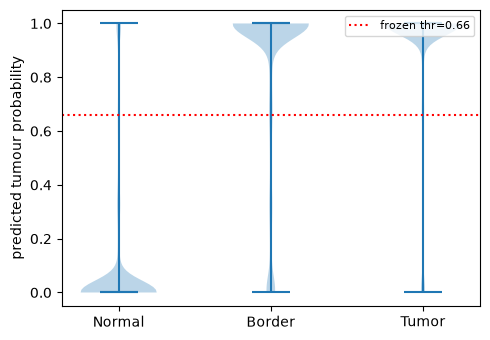

In [15]:
# ============================================================
# 14. Level A per-compartment + Border sensitivity
# ============================================================
pc = per_compartment(yv, probA, ctv_ids, BEST_THR)
print("Level A per compartment:"); print(pc.to_string(index=False))
pc.to_csv(os.path.join(OUT_DIR, "levelA_per_compartment.csv"), index=False)

# ---- Border gradient: Normal < Border < Tumor is a biological prediction ----
print("\nMean predicted tumour probability by tissue of origin:")
grad = pd.DataFrame({"tissue": ["Normal", "Border", "Tumor"]})
grad["n"]         = [int((tissue_v == t).sum()) for t in grad["tissue"]]
grad["mean_prob"] = [round(float(probA[tissue_v == t].mean()), 4) for t in grad["tissue"]]
grad["pct_called_tumor"] = [round(float((probA[tissue_v == t] >= BEST_THR).mean()), 4)
                            for t in grad["tissue"]]
print(grad.to_string(index=False))
grad.to_csv(os.path.join(OUT_DIR, "border_gradient.csv"), index=False)

# ---- sensitivity: drop Border, evaluate tumour core vs normal ----
core = tissue_v != "Border"
mC = score(yv[core], probA[core], BEST_THR)
print(f"\nBorder EXCLUDED (n={int(core.sum()):,}): "
      f"{ {k: round(v,4) for k,v in mC.items()} }")
print("95% CI:", boot_ci(yv[core], probA[core], BEST_THR))
print("\nPer compartment, Border excluded:")
print(per_compartment(yv[core], probA[core], ctv_ids[core], BEST_THR).to_string(index=False))

fig, ax = plt.subplots(figsize=(5, 3.5))
ax.violinplot([probA[tissue_v == t] for t in ["Normal", "Border", "Tumor"]], showmedians=True)
ax.axhline(BEST_THR, color="r", ls=":", label=f"frozen thr={BEST_THR:.2f}")
ax.set_xticks([1, 2, 3]); ax.set_xticklabels(["Normal", "Border", "Tumor"])
ax.set_ylabel("predicted tumour probability"); ax.legend(fontsize=8)
plt.tight_layout(); plt.savefig(os.path.join(OUT_DIR, "border_gradient.png"), dpi=300)
plt.show()

In [16]:
# ============================================================
# 15. LEVEL A-PANEL — frozen TOP_N-gene classifier -> external cohort
# ============================================================
# The clinically relevant artefact: a small fixed panel trained once on discovery and
# applied unchanged to an independent cohort. Level B (retraining on validation) cannot
# demonstrate this.
panel_idx = np.array([list(gene_names).index(g) for g in candidate_genes])
Xp, Xvp = X_expr[:, panel_idx], Xv_expr[:, panel_idx]

models_P, scaler_P, nctP = fit_full(Xp, X_ct, y, ct_ids)

# threshold refrozen on discovery OOF for THIS feature set (validation untouched)
mp, rp, ep = run_cv(Xp, X_ct, y, groups, ct_ids, gene_names[panel_idx],
                    tag="panel-CV", do_attribution=False)
oofp = ep["oof"]; mk = ~np.isnan(oofp)
f_, t_, th_ = roc_curve(y[mk], oofp[mk]); THR_P = float(th_[np.argmax(t_ - f_)])
print(f"Panel frozen threshold = {THR_P:.4f}")

for tagname, refit in [("strict", False), ("adapted", True)]:
    p = transfer_prob(models_P, scaler_P, Xvp, Xv_ct, nctP, refit_scaler=refit)
    m = score(yv, p, THR_P)
    print(f"\nLevel A-panel ({len(candidate_genes)} genes, {tagname}): "
          f"{ {k: round(v,4) for k,v in m.items()} }")
    print("95% CI:", boot_ci(yv, p, THR_P))
    if tagname == "strict":
        probP = p
        print("Per compartment:")
        print(per_compartment(yv, p, ctv_ids, THR_P).to_string(index=False))
        pd.DataFrame([m]).to_csv(os.path.join(OUT_DIR, "levelA_panel_metrics.csv"), index=False)

[panel-CV] cells=61,762 patients=23 folds=5 tumor_frac=0.748
[panel-CV] seed 0 fold 1: ROC-AUC=0.986 PR-AUC=0.995 balAcc=0.940
[panel-CV] seed 0 fold 2: ROC-AUC=0.978 PR-AUC=0.991 balAcc=0.926
[panel-CV] seed 0 fold 3: ROC-AUC=0.991 PR-AUC=0.998 balAcc=0.942
[panel-CV] seed 0 fold 4: ROC-AUC=0.993 PR-AUC=0.998 balAcc=0.953
[panel-CV] seed 0 fold 5: ROC-AUC=0.977 PR-AUC=0.989 balAcc=0.896
[panel-CV] seed 1 fold 1: ROC-AUC=0.987 PR-AUC=0.995 balAcc=0.942
[panel-CV] seed 1 fold 2: ROC-AUC=0.979 PR-AUC=0.992 balAcc=0.925
[panel-CV] seed 1 fold 3: ROC-AUC=0.989 PR-AUC=0.997 balAcc=0.936
[panel-CV] seed 1 fold 4: ROC-AUC=0.994 PR-AUC=0.998 balAcc=0.953
[panel-CV] seed 1 fold 5: ROC-AUC=0.978 PR-AUC=0.989 balAcc=0.899
[panel-CV] seed 2 fold 1: ROC-AUC=0.985 PR-AUC=0.995 balAcc=0.937
[panel-CV] seed 2 fold 2: ROC-AUC=0.979 PR-AUC=0.992 balAcc=0.924
[panel-CV] seed 2 fold 3: ROC-AUC=0.991 PR-AUC=0.998 balAcc=0.947
[panel-CV] seed 2 fold 4: ROC-AUC=0.994 PR-AUC=0.999 balAcc=0.959
[panel-CV] seed

GSE132465 থেকে top-100 gene নির্বাচন
            ↓
এই 100 gene দিয়ে GSE132465-এ model train
            ↓
GSE144735 থেকে একই 100 gene-এর expression নেওয়া
            ↓
Trained model দিয়ে prediction
            ↓
Strict ও adapted result দেখা

In [17]:
# # ============================================================
# # 16. BASELINES — does the supervised AE earn its complexity?
# # ============================================================
# from sklearn.linear_model import LogisticRegression
# from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
# from sklearn.neural_network import MLPClassifier
# try:
#     from xgboost import XGBClassifier
#     HAS_XGB = True
# except ImportError:
#     HAS_XGB = False
#     print("xgboost absent -> HistGradientBoosting used instead.")

# def make_baselines():
#     b = {
#         "LogReg_L2": LogisticRegression(max_iter=2000, C=1.0, class_weight="balanced",
#                                         n_jobs=-1),
#         "RandomForest": RandomForestClassifier(n_estimators=300, max_depth=None,
#                                                min_samples_leaf=5, class_weight="balanced",
#                                                n_jobs=-1, random_state=0),
#         "MLP_plain": MLPClassifier(hidden_layer_sizes=(512, 128), max_iter=60,
#                                    early_stopping=True, random_state=0),
#     }
#     b["XGBoost"] = (XGBClassifier(n_estimators=400, max_depth=6, learning_rate=0.1,
#                                   subsample=0.8, colsample_bytree=0.8, n_jobs=-1,
#                                   random_state=0, eval_metric="logloss", tree_method="hist")
#                     if HAS_XGB else
#                     HistGradientBoostingClassifier(max_iter=300, random_state=0))
#     return b

# def baseline_cv_and_transfer(Xd, Xv_, tag=""):
#     sgkf = StratifiedGroupKFold(n_splits=N_SPLITS, shuffle=True, random_state=0)
#     rows, oof_store = [], {}
#     for name, _ in make_baselines().items():
#         oof = np.full(len(y), np.nan)
#         for tr, te in sgkf.split(Xd, y, groups=groups):
#             s = StandardScaler().fit(Xd[tr])
#             clf = make_baselines()[name]
#             sw = make_weights(y[tr], ct_ids[tr]) if name in ("MLP_plain",) else None
#             try:
#                 clf.fit(s.transform(Xd[tr]), y[tr], sample_weight=sw) if sw is not None \
#                     else clf.fit(s.transform(Xd[tr]), y[tr])
#             except TypeError:
#                 clf.fit(s.transform(Xd[tr]), y[tr])
#             oof[te] = clf.predict_proba(s.transform(Xd[te]))[:, 1]
#         mk = ~np.isnan(oof)
#         f_, t_, th_ = roc_curve(y[mk], oof[mk]); thr_b = float(th_[np.argmax(t_ - f_)])
#         d = score(y[mk], oof[mk], thr_b)

#         s_full = StandardScaler().fit(Xd)
#         clf = make_baselines()[name]; clf.fit(s_full.transform(Xd), y)
#         pv = clf.predict_proba(s_full.transform(Xv_))[:, 1]
#         v = score(yv, pv, thr_b)

#         rows.append({"model": name, "features": tag,
#                      "disc_roc": round(d["roc_auc"], 4), "disc_ba": round(d["bal_acc"], 4),
#                      "valA_roc": round(v["roc_auc"], 4), "valA_pr": round(v["pr_auc"], 4),
#                      "valA_ba": round(v["bal_acc"], 4)})
#         oof_store[name] = pv
#         print(f"  [{tag}] {name:14s} disc BA={d['bal_acc']:.3f} | "
#               f"Level-A BA={v['bal_acc']:.3f} ROC={v['roc_auc']:.3f}")
#     return pd.DataFrame(rows), oof_store

# print("=== full feature space ===")
# bl_full, _ = baseline_cv_and_transfer(X_expr, Xv_expr, tag=f"all({n_genes})")
# print("\n=== candidate panel only ===")
# bl_pan, _  = baseline_cv_and_transfer(Xp, Xvp, tag=f"panel({len(candidate_genes)})")

# sae_row = pd.DataFrame([
#     {"model": "SAE (ours)", "features": f"all({n_genes})",
#      "disc_roc": round(metrics_disc["roc_auc"].mean(), 4),
#      "disc_ba": round(metrics_disc["bal_acc"].mean(), 4),
#      "valA_roc": round(resA["strict (discovery scaler)"]["metrics"]["roc_auc"], 4),
#      "valA_pr": round(resA["strict (discovery scaler)"]["metrics"]["pr_auc"], 4),
#      "valA_ba": round(resA["strict (discovery scaler)"]["metrics"]["bal_acc"], 4)},
#     {"model": "cell-type only", "features": "onehot(5)", "disc_roc": round(BASE_CT["roc_auc"], 4),
#      "disc_ba": round(BASE_CT["bal_acc"], 4), "valA_roc": np.nan, "valA_pr": np.nan,
#      "valA_ba": np.nan}])

# bench = pd.concat([sae_row, bl_full, bl_pan], ignore_index=True)
# bench.to_csv(os.path.join(OUT_DIR, "baseline_benchmark.csv"), index=False)
# print("\n=== BENCHMARK ===="); print(bench.to_string(index=False))

এই ধাপে validation dataset-এর মধ্যেই LOPO cross-validation করা হয়েছে:

মোট ৬ জন patient।
৫ জন patient দিয়ে ১০০-gene model train, বাকি ১ জনকে test।
এভাবে প্রত্যেক patient একবার test হয়েছে।
গড় balanced accuracy: 0.8491 ± 0.0883।

তারপর candidate ১০০ gene আসলেই বিশেষ কি না যাচাই করতে ৩০টি random ১০০-gene panel চালানো হয়েছে:

In [18]:
# ============================================================
# 17. LEVEL B — validation-side LOPO CV + random-panel null
# ============================================================
# Only 6 patients: 5-fold produces one-patient test folds with enormous variance.
# Leave-one-patient-out is the honest design and yields a per-patient table.
def lopo_cv(Xe, Xc, yy, gg, cc, seeds=SEEDS, epochs=EPOCHS):
    rows, probs = [], np.full((len(seeds), len(yy)), np.nan, dtype=np.float32)
    pats = np.unique(gg)
    for si, sd in enumerate(seeds):
        for p in pats:
            te = gg == p; tr = ~te
            if len(np.unique(yy[tr])) < 2 or len(np.unique(yy[te])) < 2:
                continue
            s = StandardScaler().fit(Xe[tr])
            n_c = Xc.shape[1] if (Xc is not None and USE_ONEHOT) else 0
            Xtr = np.hstack([s.transform(Xe[tr]), Xc[tr]]).astype(np.float32) if n_c \
                  else s.transform(Xe[tr]).astype(np.float32)
            Xte = np.hstack([s.transform(Xe[te]), Xc[te]]).astype(np.float32) if n_c \
                  else s.transform(Xe[te]).astype(np.float32)
            mdl = train_one_fold(Xtr, yy[tr], make_weights(yy[tr], cc[tr]),
                                 Xe.shape[1], n_c, seed=sd, epochs=epochs)
            pr = predict_prob(mdl, Xte); probs[si, te] = pr
            m = score(yy[te], pr); m.update({"seed": sd, "patient": p, "n": int(te.sum())})
            rows.append(m)
    return pd.DataFrame(rows), np.nanmean(probs, axis=0)

lb, prob_lb = lopo_cv(Xvp, Xv_ct, yv, groups_v, ctv_ids)
per_pat = lb.groupby("patient")[["roc_auc", "pr_auc", "bal_acc"]].mean().round(4)
print("Level B (LOPO, candidate panel) — per patient:"); print(per_pat)
print(f"\nMean balAcc = {per_pat['bal_acc'].mean():.4f} "
      f"± {per_pat['bal_acc'].std():.4f} (SD across patients)")
lb.to_csv(os.path.join(OUT_DIR, "levelB_lopo.csv"), index=False)
OBS_BA = per_pat["bal_acc"].mean()

# ---- null: random panels of the same size ----
N_NULL = 30          # raise to 100 if time allows
rng = np.random.RandomState(0); null_ba = []
for b in range(N_NULL):
    ridx = rng.choice(n_genes, len(candidate_genes), replace=False)
    lb_r, _ = lopo_cv(Xv_expr[:, ridx], Xv_ct, yv, groups_v, ctv_ids, seeds=(0,))
    null_ba.append(lb_r.groupby("patient")["bal_acc"].mean().mean())
    if (b + 1) % 10 == 0:
        print(f"  null {b+1}/{N_NULL}: running mean = {np.mean(null_ba):.4f}")

null_ba = np.array(null_ba)
p_emp = (np.sum(null_ba >= OBS_BA) + 1) / (len(null_ba) + 1)
print(f"\nObserved BA={OBS_BA:.4f} | random panels {null_ba.mean():.4f} "
      f"± {null_ba.std():.4f} | empirical p={p_emp:.4f}")
np.save(os.path.join(OUT_DIR, "levelB_null_ba.npy"), null_ba)

Level B (LOPO, candidate panel) — per patient:
         roc_auc  pr_auc  bal_acc
patient                          
KUL01     0.9899  0.9933   0.9536
KUL19     0.8653  0.9518   0.7129
KUL21     0.9857  0.9953   0.9353
KUL28     0.9314  0.9254   0.8486
KUL30     0.8916  0.8732   0.8043
KUL31     0.9500  0.9476   0.8398

Mean balAcc = 0.8491 ± 0.0883 (SD across patients)
  null 10/30: running mean = 0.7014
  null 20/30: running mean = 0.6977
  null 30/30: running mean = 0.7039

Observed BA=0.8491 | random panels 0.7039 ± 0.0241 | empirical p=0.0323


In [19]:
# ============================================================
# 18. Validation-side attribution + hypergeometric concordance
# ============================================================
from scipy.stats import hypergeom

mv, rank_val, ev = run_cv(Xv_expr, Xv_ct, yv, groups_v, ctv_ids, gene_names,
                          tag="validation-attr", ct_names=ct_cols,
                          do_attribution=True, n_splits=min(5, len(np.unique(groups_v))))
rank_val.to_csv(os.path.join(OUT_DIR, "validation_attribution_ranking.csv"), index=False)

disc_top = set(rank_df.head(TOP_N)["gene"])
val_top  = set(rank_val.head(TOP_N)["gene"])
ov = sorted(disc_top & val_top)
M, n_, N_, k = n_genes, TOP_N, TOP_N, len(ov)

p_hg = hypergeom.sf(k - 1, M, n_, N_)
exp_k = n_ * N_ / M
jac = k / len(disc_top | val_top)

print(f"\nUniverse={M} | top-{TOP_N} each | overlap={k} | expected={exp_k:.2f} "
      f"| fold={k/exp_k:.2f}x | Jaccard={jac:.4f}")
print(f"Hypergeometric p = {p_hg:.3e}")

final = rank_df[rank_df["gene"].isin(ov)][
    ["rank", "gene", "selection_freq", "lfc_adjusted", "direction"]].copy()
final = final.merge(rank_val[["gene", "rank", "selection_freq"]], on="gene",
                    suffixes=("_disc", "_val")).sort_values("rank_disc")
final.to_csv(os.path.join(OUT_DIR, "FINAL_reproducible_biomarkers.csv"), index=False)
print(f"\nFINAL reproducible panel: {len(final)} genes"); print(final.to_string(index=False))

json.dump({"overlap": k, "expected": round(exp_k, 3), "fold": round(k/exp_k, 3),
           "jaccard": round(jac, 4), "hypergeom_p": float(p_hg), "universe": M,
           "top_n": TOP_N}, open(os.path.join(OUT_DIR, "overlap_stats.json"), "w"), indent=2)

[validation-attr] cells=26,523 patients=6 folds=5 tumor_frac=0.647
[validation-attr] seed 0 fold 1: ROC-AUC=0.841 PR-AUC=0.942 balAcc=0.706
[validation-attr] seed 0 fold 2: ROC-AUC=0.962 PR-AUC=0.980 balAcc=0.899
[validation-attr] seed 0 fold 3: ROC-AUC=0.992 PR-AUC=0.995 balAcc=0.952
[validation-attr] seed 0 fold 4: ROC-AUC=0.923 PR-AUC=0.891 balAcc=0.845
[validation-attr] seed 0 fold 5: ROC-AUC=0.937 PR-AUC=0.897 balAcc=0.856
[validation-attr] seed 1 fold 1: ROC-AUC=0.866 PR-AUC=0.951 balAcc=0.731
[validation-attr] seed 1 fold 2: ROC-AUC=0.940 PR-AUC=0.969 balAcc=0.870
[validation-attr] seed 1 fold 3: ROC-AUC=0.962 PR-AUC=0.983 balAcc=0.918
[validation-attr] seed 1 fold 4: ROC-AUC=0.918 PR-AUC=0.893 balAcc=0.844
[validation-attr] seed 1 fold 5: ROC-AUC=0.940 PR-AUC=0.906 balAcc=0.863
[validation-attr] seed 2 fold 1: ROC-AUC=0.828 PR-AUC=0.936 balAcc=0.700
[validation-attr] seed 2 fold 2: ROC-AUC=0.934 PR-AUC=0.965 balAcc=0.862
[validation-attr] seed 2 fold 3: ROC-AUC=0.991 PR-AUC=0.9

এই ধাপে validation GSE144735 dataset-এ Integrated Gradients দিয়ে আলাদাভাবে top-100 important gene বের করা হয়েছে।

তারপর:

Discovery top-100
        ∩
Validation top-100
        ↓
42টি common gene

In [ ]:
ct_attr = disc_extras["ct_attr"]
if ct_attr is None:
    raise RuntimeError("No per-cell-type attribution matrix found in disc_extras.")

# Numeric raw IG attribution by cell compartment for the full Top-100 panel.
scores = ct_attr.loc[candidate_genes].select_dtypes(include="number").copy()
row_sums = scores.sum(axis=1).replace(0, np.nan)
top100_share = scores.div(row_sums, axis=0).fillna(0.0) * 100

top100_ct = top100_share.copy()
top100_ct["dominant_cell_type"] = top100_share.idxmax(axis=1)
top100_ct["dominant_attribution_share"] = top100_share.max(axis=1)
top100_ct["dominant_raw_score"] = scores.max(axis=1)

top100_share.to_csv(os.path.join(OUT_DIR, "panel100_compartment_attribution.csv"))
scores.to_csv(os.path.join(OUT_DIR, "panel100_compartment_attribution_raw.csv"))
top100_ct.reset_index(names="gene").to_csv(
    os.path.join(OUT_DIR, "panel100_dominant_compartment.csv"), index=False
)

display(top100_ct)

print("\nDominant cell-type of Top-100 genes count:")
print(top100_ct["dominant_cell_type"].value_counts())
print("\nFiles written:")
for f in [
    "panel100_compartment_attribution.csv",
    "panel100_compartment_attribution_raw.csv",
    "panel100_dominant_compartment.csv",
]:
    print(f"  {os.path.join(OUT_DIR, f)}  ({'OK' if os.path.exists(os.path.join(OUT_DIR, f)) else 'MISSING'})")


,ct_B cells,ct_Epithelial cells,ct_Myeloids,ct_Stromal cells,ct_T cells,dominant_cell_type,dominant_score
CFD,1.822476,1.408716,1.701399,1.666269,1.965740,ct_T cells,1.965740
B2M,0.908999,3.273147,0.930326,1.137075,1.354433,ct_Epithelial cells,3.273147
PHGR1,1.517487,1.970556,1.454777,1.294477,1.688830,ct_Epithelial cells,1.970556
TFF3,0.782468,1.878950,0.533217,0.561510,0.579403,ct_Epithelial cells,1.878950
CLDN4,0.748506,1.878614,0.465344,0.390232,0.510918,ct_Epithelial cells,1.878614
...,...,...,...,...,...,...,...
BGN,0.151205,0.113293,0.146247,1.817155,0.133120,ct_Stromal cells,1.817155
FN1,0.190443,0.176585,0.292023,0.927922,0.173495,ct_Stromal cells,0.927922
RAC2,0.255659,0.150043,0.180052,0.175301,0.336070,ct_T cells,0.336070
SPARC,0.183935,0.153861,0.195825,1.132031,0.169114,ct_Stromal cells,1.132031



Top-100 genes-এর dominant cell-type count:
dominant_cell_type
ct_Epithelial cells    27
ct_Stromal cells       22
ct_T cells             21
ct_Myeloids            21
ct_B cells              9
Name: count, dtype: int64


Share of |IG| per compartment (%), rows sum to 100; uniform = 20%:
            ct_B cells  ct_Epithelial cells  ct_Myeloids  ct_Stromal cells  ct_T cells
CFD               21.3                 16.4         19.9              19.5        23.0
B2M               12.0                 43.0         12.2              15.0        17.8
PHGR1             19.1                 24.9         18.4              16.3        21.3
TFF3              18.0                 43.3         12.3              13.0        13.4
DCN               16.3                 14.4         16.1              35.4        17.7
GUCA2A            20.7                 19.0         20.2              18.7        21.4
KRT18             16.3                 48.5         10.8              11.2        13.1
ADAMDEC1          19.6                 16.7         23.2              19.8        20.7
ZG16              21.3                 17.6         20.6              19.4        21.0
HLA-B             18.5                 30.3         15.4       

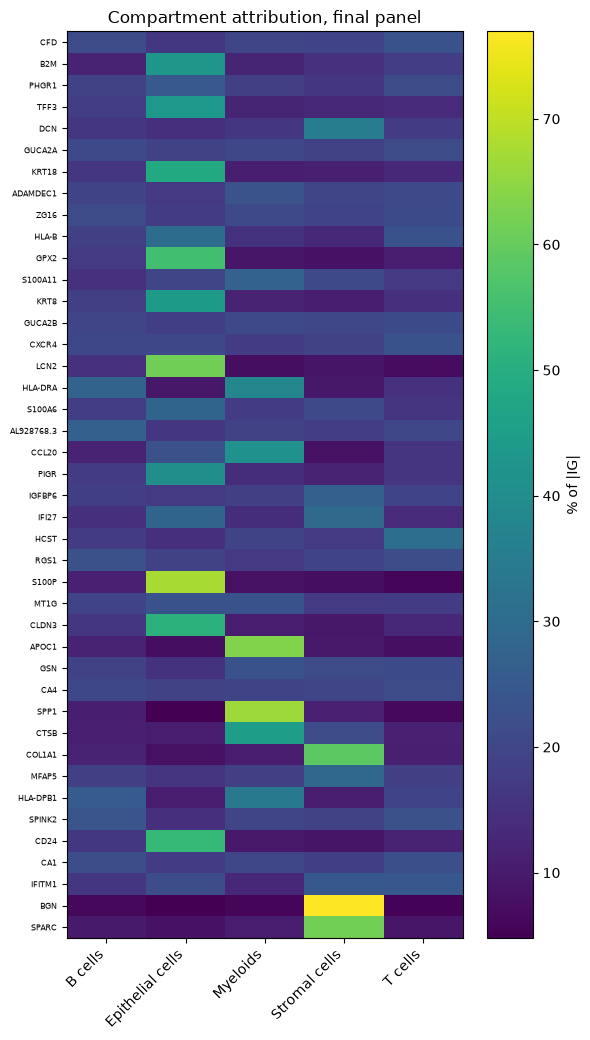

In [20]:
# ============================================================
# 19. Is the signal epithelium-only? (per-compartment attribution)
# ============================================================
ct_attr = disc_extras.get("ct_attr")
if ct_attr is not None:
    sub = ct_attr.loc[[g for g in final["gene"] if g in ct_attr.index]]
    rown = sub.div(sub.sum(axis=1), axis=0) * 100
    print("Share of |IG| per compartment (%), rows sum to 100; uniform = 20%:")
    print(rown.round(1).to_string())
    rown.to_csv(os.path.join(OUT_DIR, "final_panel_compartment_attribution.csv"))

    fig, ax = plt.subplots(figsize=(6, max(4, 0.25 * len(rown))))
    im = ax.imshow(rown.values, aspect="auto", cmap="viridis")
    ax.set_xticks(range(rown.shape[1]))
    ax.set_xticklabels([c.replace("ct_", "") for c in rown.columns], rotation=45, ha="right")
    ax.set_yticks(range(len(rown))); ax.set_yticklabels(rown.index, fontsize=6)
    plt.colorbar(im, label="% of |IG|"); plt.title("Compartment attribution, final panel")
    plt.tight_layout()
    plt.savefig(os.path.join(OUT_DIR, "compartment_attribution_heatmap.png"), dpi=300)
    plt.show()

In [21]:
# ============================================================
# 20. Ablations: one-hot, normalisation, reconstruction, IEGs
# ============================================================
def ablate(name, use_onehot=USE_ONEHOT, norm=NORM_LAYER, alpha=ALPHA_RECON):
    global USE_ONEHOT, ALPHA_RECON
    ko, ka = USE_ONEHOT, ALPHA_RECON
    USE_ONEHOT, ALPHA_RECON = use_onehot, alpha
    try:
        md, _, ed = run_cv(X_expr, X_ct, y, groups, ct_ids, gene_names,
                           tag=name, do_attribution=False, seeds=(0,))
        mo, sc_, nc = fit_full(X_expr, X_ct, y, ct_ids, seeds=(0,),
                               use_onehot=use_onehot, norm=norm)
        pv = transfer_prob(mo, sc_, Xv_expr, Xv_ct, nc)
        oo = ed["oof"]; mk = ~np.isnan(oo)
        f_, t_, th_ = roc_curve(y[mk], oo[mk]); thr_a = float(th_[np.argmax(t_ - f_)])
        v = score(yv, pv, thr_a)
        return {"ablation": name, "onehot": use_onehot, "norm": norm, "alpha_recon": alpha,
                "disc_ba": round(md["bal_acc"].mean(), 4),
                "valA_ba": round(v["bal_acc"], 4), "valA_roc": round(v["roc_auc"], 4)}
    finally:
        USE_ONEHOT, ALPHA_RECON = ko, ka

abl = pd.DataFrame([
    ablate("full (primary)"),
    ablate("no cell-type one-hot", use_onehot=False),
    ablate("no reconstruction (plain classifier)", alpha=0.0),
])
abl.to_csv(os.path.join(OUT_DIR, "ablations.csv"), index=False)
print(abl.to_string(index=False))
print("\nIf 'no cell-type one-hot' transfers BETTER, the covariate was leaking a "
      "cohort-specific prior and should be dropped from the primary model.")
print("For the dissociation-IEG sensitivity, set EXCLUDE_IEG=False in Cell 1 and "
      "re-run Part 1 + Cells 12-19; report both panels.")

[full (primary)] cells=61,762 patients=23 folds=5 tumor_frac=0.748
[full (primary)] seed 0 fold 1: ROC-AUC=0.988 PR-AUC=0.996 balAcc=0.942
[full (primary)] seed 0 fold 2: ROC-AUC=0.955 PR-AUC=0.981 balAcc=0.884
[full (primary)] seed 0 fold 3: ROC-AUC=0.991 PR-AUC=0.997 balAcc=0.952
[full (primary)] seed 0 fold 4: ROC-AUC=0.986 PR-AUC=0.995 balAcc=0.933
[full (primary)] seed 0 fold 5: ROC-AUC=0.980 PR-AUC=0.990 balAcc=0.909

=== [full (primary)] summary (mean over seeds, ±SD across folds) ===
           mean  sd_across_folds
roc_auc  0.9800           0.0146
pr_auc   0.9919           0.0065
bal_acc  0.9237           0.0276
f1       0.9499           0.0328
[no cell-type one-hot] cells=61,762 patients=23 folds=5 tumor_frac=0.748
[no cell-type one-hot] seed 0 fold 1: ROC-AUC=0.987 PR-AUC=0.995 balAcc=0.931
[no cell-type one-hot] seed 0 fold 2: ROC-AUC=0.960 PR-AUC=0.983 balAcc=0.883
[no cell-type one-hot] seed 0 fold 3: ROC-AUC=0.989 PR-AUC=0.996 balAcc=0.947
[no cell-type one-hot] seed 0 f

In [22]:
# ============================================================
# 21. Manuscript summary table
# ============================================================
S = {
    "discovery_cells": int(len(y)), "discovery_patients": int(len(np.unique(groups))),
    "validation_cells": int(len(yv)), "validation_patients": int(len(np.unique(groups_v))),
    "features": int(n_genes), "IEGs_excluded": bool(EXCLUDE_IEG),
    "celltype_only_BA": round(BASE_CT["bal_acc"], 4),
    "discovery_CV_ROC": round(metrics_disc["roc_auc"].mean(), 4),
    "discovery_CV_BA": round(metrics_disc["bal_acc"].mean(), 4),
    "frozen_threshold": round(BEST_THR, 4),
    "levelA_BA_strict": round(resA["strict (discovery scaler)"]["metrics"]["bal_acc"], 4),
    "levelA_BA_adapted": round(resA["adapted (validation scaler)"]["metrics"]["bal_acc"], 4),
    "levelA_ROC_strict": round(resA["strict (discovery scaler)"]["metrics"]["roc_auc"], 4),
    "levelB_LOPO_BA": round(OBS_BA, 4),
    "levelB_null_BA": round(float(null_ba.mean()), 4),
    "levelB_empirical_p": round(float(p_emp), 4),
    "candidate_panel": int(len(candidate_genes)),
    "final_reproducible_panel": int(len(final)),
    "overlap_hypergeom_p": float(p_hg),
}
json.dump(S, open(os.path.join(OUT_DIR, "SUMMARY.json"), "w"), indent=2)
print(json.dumps(S, indent=2))
print("\nOutputs in:", OUT_DIR)
print("Downstream (notebook 05) input: FINAL_reproducible_biomarkers.csv")
print("Before enrichment/STRING: update symbols to current HGNC "
      "(SEPP1->SELENOP, C12orf75->OCC1) and drop clone-based IDs.")

{
  "discovery_cells": 61762,
  "discovery_patients": 23,
  "validation_cells": 26523,
  "validation_patients": 6,
  "features": 2934,
  "IEGs_excluded": true,
  "celltype_only_BA": 0.6928,
  "discovery_CV_ROC": 0.9803,
  "discovery_CV_BA": 0.924,
  "frozen_threshold": 0.6616,
  "levelA_BA_strict": 0.8845,
  "levelA_BA_adapted": 0.8519,
  "levelA_ROC_strict": 0.957,
  "levelB_LOPO_BA": 0.8491,
  "levelB_null_BA": 0.7039,
  "levelB_empirical_p": 0.0323,
  "candidate_panel": 100,
  "final_reproducible_panel": 42,
  "overlap_hypergeom_p": 1.100636010213186e-38
}

Outputs in: optionB_outputs
Downstream (notebook 05) input: FINAL_reproducible_biomarkers.csv
Before enrichment/STRING: update symbols to current HGNC (SEPP1->SELENOP, C12orf75->OCC1) and drop clone-based IDs.


In [23]:
# ============================================================
# 22. Downstream-ready export  (creates the three files notebook 05 needs)
# ============================================================
# Self-contained: uses in-memory objects when the kernel is still alive, otherwise
# rebuilds them from the CSVs written earlier in this notebook.
import os, re, json
import numpy as np, pandas as pd

OUT_DIR = globals().get("OUT_DIR", "optionB_outputs")
os.makedirs(OUT_DIR, exist_ok=True)
P = lambda f: os.path.join(OUT_DIR, f)

# ---------- recover rank_df ----------
if "rank_df" in globals():
    rank_df = globals()["rank_df"].copy()
else:
    rank_df = pd.read_csv(P("optionB_gene_attribution_ranking.csv"))
    print("rank_df restored from CSV")

# ---------- recover the candidate panel ----------
if "candidate_genes" in globals():
    candidate_genes = list(globals()["candidate_genes"])
elif "is_candidate_biomarker" in rank_df.columns:
    candidate_genes = rank_df.loc[rank_df["is_candidate_biomarker"], "gene"].tolist()
else:
    TOP_N = globals().get("TOP_N", 100)
    candidate_genes = rank_df.nsmallest(TOP_N, "rank")["gene"].tolist()
    rank_df["is_candidate_biomarker"] = rank_df["gene"].isin(candidate_genes)

# ---------- recover the reproducible panel ----------
if "final" in globals():
    final = globals()["final"].copy()
elif os.path.exists(P("FINAL_reproducible_biomarkers.csv")):
    final = pd.read_csv(P("FINAL_reproducible_biomarkers.csv"))
else:
    final = pd.DataFrame({"gene": []})
    print("WARNING: reproducible panel not found — panel42 will be empty.")

# ---------- recover the full feature space (enrichment background) ----------
if "gene_names" in globals():
    all_genes = list(globals()["gene_names"])
elif os.path.exists(P("optionB_feature_genes.csv")):
    all_genes = pd.read_csv(P("optionB_feature_genes.csv"))["gene"].tolist()
else:
    all_genes = rank_df["gene"].tolist()
    print("WARNING: full feature space missing — background falls back to ranked genes.")

# ---------- direction: near-zero log2FC carries no usable sign ----------
AMB = 0.05
if "lfc_adjusted" in rank_df.columns:
    rank_df["direction"] = np.where(
        rank_df["lfc_adjusted"].abs() < AMB, "ambiguous",
        np.where(rank_df["lfc_adjusted"] > 0, "UP_in_tumor", "DOWN_in_tumor"))
else:
    rank_df["lfc_adjusted"] = np.nan
    rank_df["direction"] = "unknown"

# ---------- attribution specificity + Top-100 compartment exports ----------
spec = None
ca = None
if "ct_attr" in globals() and globals()["ct_attr"] is not None:
    ca = globals()["ct_attr"]
elif "disc_extras" in globals() and globals()["disc_extras"].get("ct_attr") is not None:
    ca = globals()["disc_extras"]["ct_attr"]
elif os.path.exists(P("panel100_compartment_attribution.csv")):
    ca = pd.read_csv(P("panel100_compartment_attribution.csv"), index_col=0)
elif os.path.exists(P("final_panel_compartment_attribution.csv")):
    ca = pd.read_csv(P("final_panel_compartment_attribution.csv"), index_col=0)

if ca is not None:
    ca = ca.select_dtypes(include="number").copy()
    row_totals = ca.sum(axis=1)
    valid_totals = row_totals.dropna()
    is_percent_share = (
        len(valid_totals) > 0
        and valid_totals.between(99.0, 101.0).mean() > 0.80
    )
    share = ca.copy() if is_percent_share else ca.div(
        row_totals.replace(0, np.nan), axis=0
    ).fillna(0.0) * 100
    spec = share.max(axis=1) / (100.0 / share.shape[1])

    top100_share = share.reindex(candidate_genes).dropna(how="all")
    top100_share.to_csv(P("panel100_compartment_attribution.csv"))
    dominant = top100_share.copy()
    dominant["dominant_cell_type"] = top100_share.idxmax(axis=1)
    dominant["dominant_attribution_share"] = top100_share.max(axis=1)
    dominant.reset_index(names="gene").to_csv(P("panel100_dominant_compartment.csv"), index=False)

rank_df["attr_specificity"] = (spec.reindex(rank_df["gene"]).values
                               if spec is not None else np.nan)

# ---------- HGNC harmonisation ----------
# Outdated symbols are silently dropped by g:Profiler / clusterProfiler / STRING, which
# is the usual reason a Set A n Set B n Set C n Set D intersection comes back empty.
HGNC_FIX = {"SEPP1":"SELENOP", "C12orf75":"OCC1", "SEPW1":"SELENOW",
            "CTGF":"CCN2", "CYR61":"CCN1", "KIAA0101":"PCLAF",
            "FAM64A":"PIMREG", "GPR56":"ADGRG1", "TMEM66":"SARAF"}

def harmonise(genes):
    """Clone-based identifiers always carry a version dot (AL928768.3); real HGNC
    symbols never do. Matching on an 'AL'/'AC' prefix would wrongly drop ALB and ACTB."""
    out, dropped = [], []
    for g in genes:
        g2 = HGNC_FIX.get(str(g).strip(), str(g).strip())
        (dropped if ("." in g2 or re.match(r"^LINC\d{5}$", g2)) else out).append(g2)
    return list(dict.fromkeys(out)), dropped

panel100, drop100 = harmonise(candidate_genes)
panel42,  drop42  = harmonise(final["gene"].tolist() if len(final) else [])
background, _     = harmonise(all_genes)

print(f"Candidate panel  : {len(candidate_genes)} -> {len(panel100)} mappable")
print(f"Reproducible     : {len(final)} -> {len(panel42)} mappable")
print(f"Background       : {len(background)} genes")
print("Renamed to current HGNC:", sorted({g for g in candidate_genes if g in HGNC_FIX}) or "none")
print("Dropped (unmappable)   :", sorted(set(drop100 + drop42)) or "none")

# ---------- artifact regression check ----------
BAD = {"HSPH1","HSPA1A","HSPA1B","FOS","FOSB","JUN","JUNB","EGR1","KLF4","NR4A2",
       "GADD45B","IER3","DUSP1","ZFP36","ZNF331","ATF3","SOCS3","PPP1R15A"}
hit = sorted(set(panel100) & BAD)
print("\nHeat-shock / dissociation IEGs in panel:", hit if hit else "NONE")

# ---------- write the three files notebook 05 consumes ----------
keep = [c for c in ["rank","gene","selection_freq","mean_abs_attr","mean_signed_attr",
                    "lfc_adjusted","lfc_epithelial","direction","attr_specificity"]
        if c in rank_df.columns]
tbl = rank_df[rank_df["gene"].isin(candidate_genes)][keep].copy()
tbl["gene_hgnc"] = [HGNC_FIX.get(g, g) for g in tbl["gene"]]
tbl["mappable"]  = tbl["gene_hgnc"].isin(panel100)
tbl.sort_values("rank").to_csv(P("DOWNSTREAM_panel100.csv"), index=False)

if len(final):
    fin = final.copy()
    dmap = rank_df.set_index("gene")["direction"]
    fin["direction"] = fin["gene"].map(dmap)
    fin["gene_hgnc"] = [HGNC_FIX.get(g, g) for g in fin["gene"]]
    fin["mappable"]  = fin["gene_hgnc"].isin(panel42)
else:
    fin = pd.DataFrame(columns=["gene","direction","gene_hgnc","mappable"])
fin.to_csv(P("DOWNSTREAM_panel42.csv"), index=False)

for fname, lst in [("panel100_genes.txt", panel100),
                   ("panel42_genes.txt", panel42),
                   ("background_genes.txt", background)]:
    with open(P(fname), "w") as fh:
        fh.write("\n".join(lst))

print("\nDirection split (panel 100):")
print(tbl["direction"].value_counts().to_string())
if tbl["attr_specificity"].notna().any():
    low = tbl[tbl["attr_specificity"] < 1.15][["gene","attr_specificity"]]
    print("\nLow-specificity genes (<1.15, possibly ambient RNA):")
    print(low.round(2).to_string(index=False) if len(low) else "  none")

print("\nFiles written:")
for f in ["DOWNSTREAM_panel100.csv","DOWNSTREAM_panel42.csv",
          "panel100_genes.txt","panel42_genes.txt","background_genes.txt"]:
    print(f"  {P(f)}  ({'OK' if os.path.exists(P(f)) else 'MISSING'})")

Candidate panel  : 100 -> 99 mappable
Reproducible     : 42 -> 41 mappable
Background       : 2632 genes
Renamed to current HGNC: ['C12orf75', 'SEPP1']
Dropped (unmappable)   : ['AL928768.3']

Heat-shock / dissociation IEGs in panel: NONE

Direction split (panel 100):
direction
UP_in_tumor      54
DOWN_in_tumor    42
ambiguous         4

Low-specificity genes (<1.15, possibly ambient RNA):
  gene  attr_specificity
   CFD              1.15
GUCA2A              1.07
  ZG16              1.07
GUCA2B              1.05
 CXCR4              1.15
  RGS1              1.14
   GSN              1.15
   CA4              1.06
  AQP8              1.09
   CA1              1.11

Files written:
  optionB_outputs/DOWNSTREAM_panel100.csv  (OK)
  optionB_outputs/DOWNSTREAM_panel42.csv  (OK)
  optionB_outputs/panel100_genes.txt  (OK)
  optionB_outputs/panel42_genes.txt  (OK)
  optionB_outputs/background_genes.txt  (OK)
